In [1]:
import os
import sys
src_path = '../../../src'
if src_path not in sys.path:
    sys.path.append(src_path)
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime
import seaborn as sns
from json import loads, dumps
from tqdm import tqdm
from enum import Enum
from sklearn.metrics import mean_squared_error
from configs import SetupEnum, MeasurementDataEnum, ErrorEnum
from parameter_tuners.ensemble_kalman_filter_parameter_tuner import EnsembleKalmanFilterParameterTuner

%matplotlib inline
np.random.seed(777)

In [2]:
n_samples = [int(n) for n in np.logspace(5, 12, base=2, num=8).tolist()]
n_samples

[32, 64, 128, 256, 512, 1024, 2048, 4096]

In [3]:
root_path = "../../../"

file_export_path = os.path.join(root_path, "exports/ensemble_kalman_filter")
kitti_root_dir = os.path.join(root_path, "data")
vo_root_dir = os.path.join(root_path, "vo_estimates")

kitti_dataset = "0033"
run_filter = True
error_weight = 0.8

# Setup1 (IMU, VO)

In [4]:
tuner_setup1 = EnsembleKalmanFilterParameterTuner(
    n_samples=n_samples,
    setup=SetupEnum.SETUP_1,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    measurement_type=MeasurementDataEnum.DROPOUT
)

In [5]:
if run_filter:
    tuner_setup1.run()
else:
    tuner_setup1.load_df()

Setting dropout ratio by 0.0
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:49<00:00, 51.23s/it]


Setting dropout ratio by 0.1
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:48<00:00, 51.06s/it]


Setting dropout ratio by 0.2
Data sampling is set to normal mode.


...

Setting dropout ratio by 0.3
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [05:57<00:00, 44.65s/it]


Setting dropout ratio by 0.4
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [04:56<00:00, 37.04s/it]

Experiment finished.


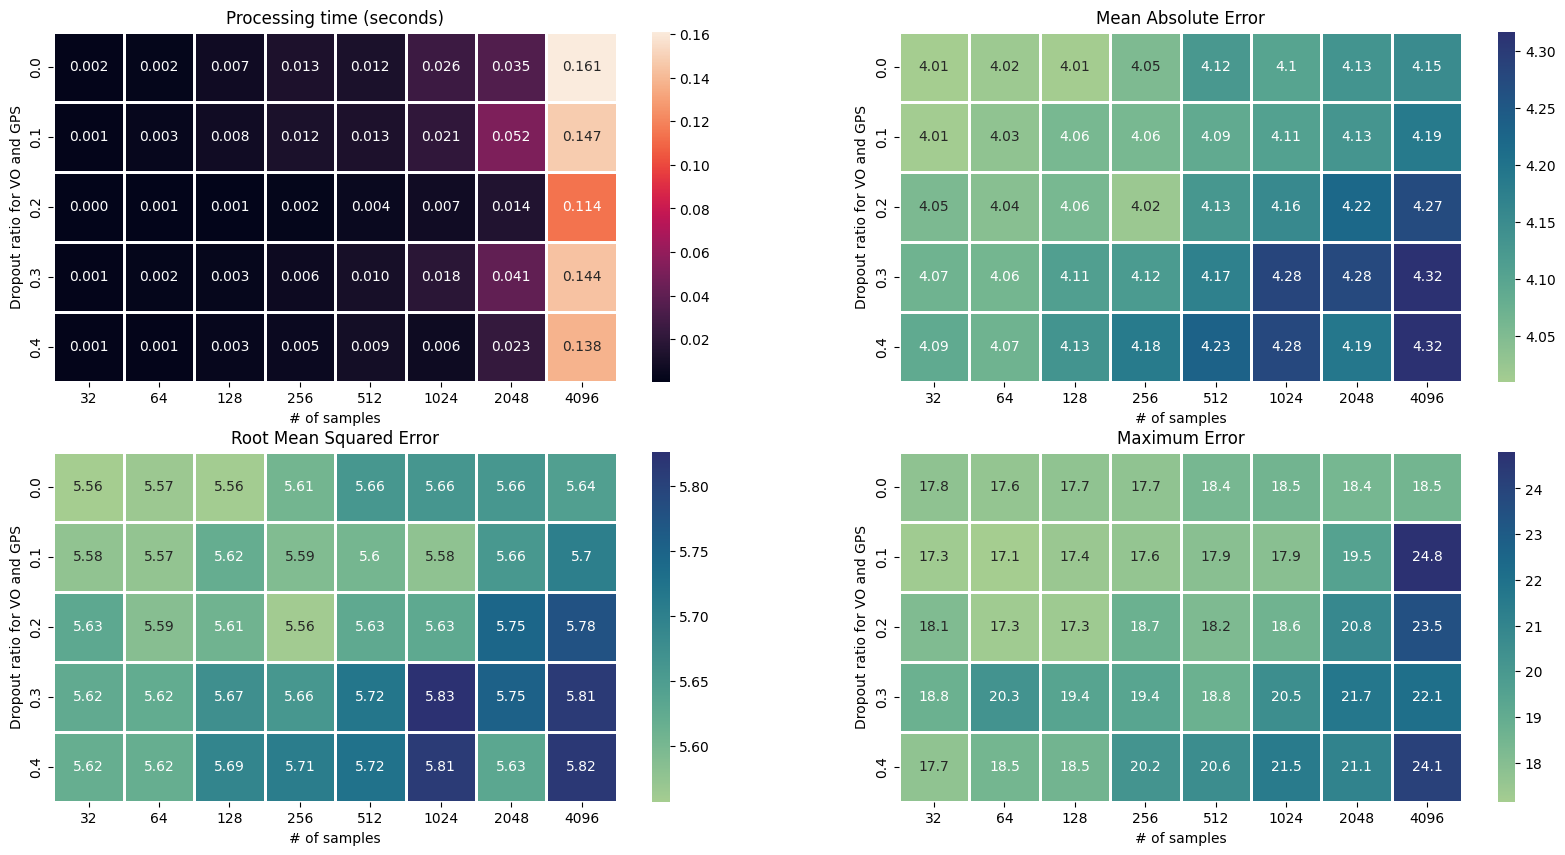

In [6]:
tuner_setup1.plot_results()

In [7]:
tuner_setup1

In [8]:
params_setup1, df1 = tuner_setup1.find_best_combination(error_weight=error_weight)
print("# of samples")
df1

# of samples


Error types,MAE,RMSE,MAX
No dropout,32,32,64
10% drop,32,32,64
20% drop,256,256,64
30% drop,64,32,32
40% drop,64,32,32


In [9]:
params_setup1

{1: [32, 32, 256, 64, 64], 2: [32, 32, 256, 32, 32], 3: [64, 64, 64, 32, 32]}

# Setup2 (IMU, VO+GPS)

In [10]:
tuner_setup2 = EnsembleKalmanFilterParameterTuner(
    n_samples=n_samples,
    setup=SetupEnum.SETUP_2,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    measurement_type=MeasurementDataEnum.DROPOUT
)

In [11]:
if run_filter:
    tuner_setup2.run()
else:
    tuner_setup2.load_df()

Setting dropout ratio by 0.0
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [09:18<00:00, 69.83s/it]


Setting dropout ratio by 0.1
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:47<00:00, 50.99s/it]


Setting dropout ratio by 0.2
Data sampling is set to normal mode.


...

Setting dropout ratio by 0.3
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [06:40<00:00, 50.05s/it]


Setting dropout ratio by 0.4
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:52<00:00, 29.01s/it]

Experiment finished.


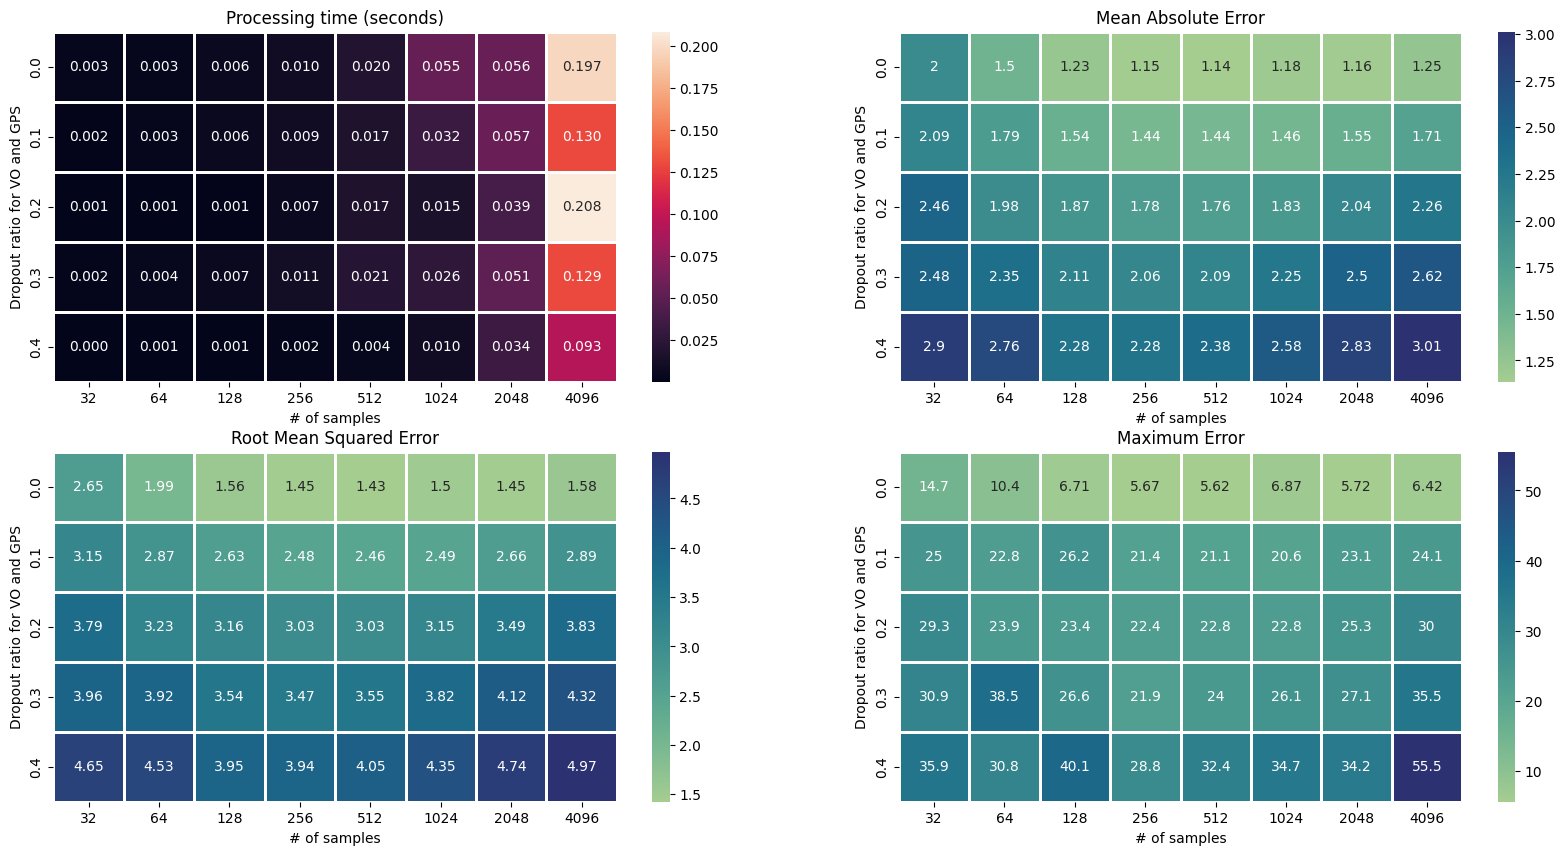

In [12]:
tuner_setup2.plot_results()

In [13]:
params_setup2, df2 = tuner_setup2.find_best_combination(error_weight=error_weight)
print("# of samples")
df2

# of samples


Error types,MAE,RMSE,MAX
No dropout,256,256,256
10% drop,256,256,256
20% drop,256,256,256
30% drop,256,256,256
40% drop,128,128,256


In [14]:
params_setup2

{1: [256, 256, 256, 256, 128],
 2: [256, 256, 256, 256, 128],
 3: [256, 256, 256, 256, 256]}

# Setup3 (INS)

In [15]:
tuner_setup3 = EnsembleKalmanFilterParameterTuner(
    n_samples=n_samples,
    setup=SetupEnum.SETUP_3,
    kitti_dataset=kitti_dataset,
    vo_root_dir=vo_root_dir,
    kitti_root_dir=kitti_root_dir,
    file_export_path=file_export_path,
    measurement_type=MeasurementDataEnum.DROPOUT
)

In [16]:
if run_filter:
    tuner_setup3.run()
else:
    tuner_setup3.load_df()

Setting dropout ratio by 0.0
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:35<00:00, 26.88s/it]


Setting dropout ratio by 0.1
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:06<00:00, 23.27s/it]


Setting dropout ratio by 0.2
Data sampling is set to normal mode.


...

Setting dropout ratio by 0.3
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [03:03<00:00, 22.90s/it]


Setting dropout ratio by 0.4
Data sampling is set to normal mode.


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 8/8 [02:56<00:00, 22.11s/it]

Experiment finished.


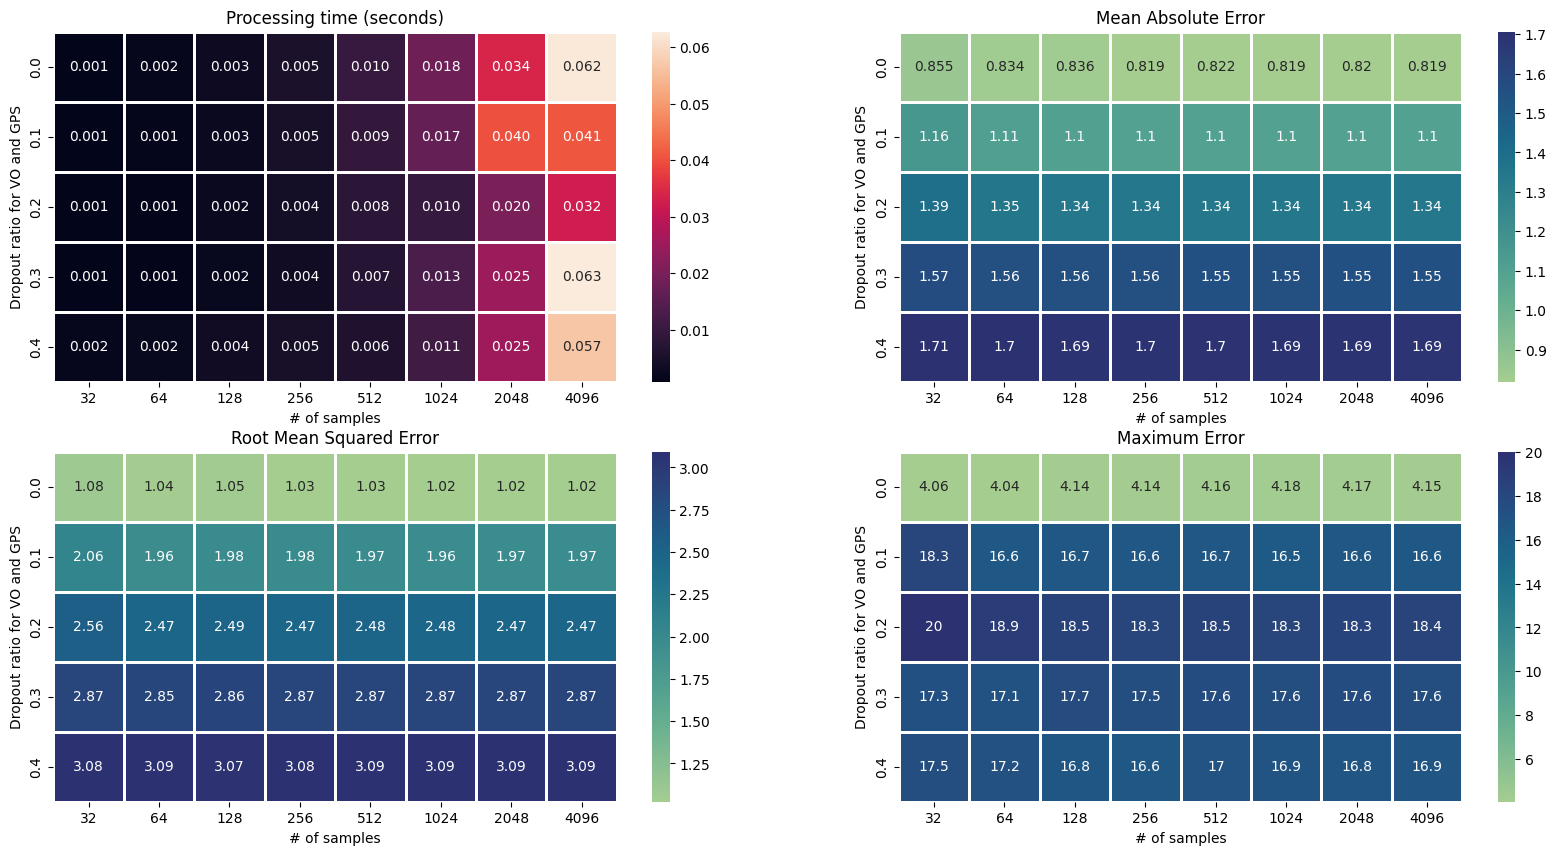

In [17]:
tuner_setup3.plot_results()

In [18]:
params_setup3, df3 = tuner_setup3.find_best_combination(error_weight=error_weight)
print("# of samples")
df3

# of samples


Error types,MAE,RMSE,MAX
No dropout,256,64,64
10% drop,64,64,64
20% drop,64,64,128
30% drop,64,64,64
40% drop,64,32,256


In [19]:
params_setup3

{1: [256, 64, 64, 64, 64], 2: [64, 64, 64, 64, 32], 3: [64, 64, 128, 64, 256]}

# Results

In [20]:
results_header = pd.MultiIndex.from_product([['Setup1 (IMU, VO)','Setup2(IMU, VO+GPS)', 'Setup3(INS)']],
                                            names=['# of ensemble'])

In [21]:
params_setup1_mae = np.array(params_setup1[ErrorEnum.MAE.value]).reshape(-1, 1)
params_setup2_mae = np.array(params_setup2[ErrorEnum.MAE.value]).reshape(-1, 1)
params_setup3_mae = np.array(params_setup3[ErrorEnum.MAE.value]).reshape(-1, 1)
best_params_mae = np.concatenate([params_setup1_mae, params_setup2_mae, params_setup3_mae], axis=1)
results_df_mae = pd.DataFrame(best_params_mae, 
                    index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                    columns=results_header)

#### MAE: optimal number of samples

In [22]:
results_df_mae

# of ensemble,"Setup1 (IMU, VO)","Setup2(IMU, VO+GPS)",Setup3(INS)
No dropout,32,256,256
10% drop,32,256,64
20% drop,256,256,64
30% drop,64,256,64
40% drop,64,128,64


In [23]:
params_setup1_rmse = np.array(params_setup1[ErrorEnum.RMSE.value]).reshape(-1, 1)
params_setup2_rmse = np.array(params_setup2[ErrorEnum.RMSE.value]).reshape(-1, 1)
params_setup3_rmse = np.array(params_setup3[ErrorEnum.RMSE.value]).reshape(-1, 1)
best_params_rmse = np.concatenate([params_setup1_rmse, params_setup2_rmse, params_setup3_rmse], axis=1)
results_df_rmse = pd.DataFrame(best_params_rmse, 
                    index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                    columns=results_header)

#### RMSE: optimal number of samples

In [24]:
results_df_rmse

# of ensemble,"Setup1 (IMU, VO)","Setup2(IMU, VO+GPS)",Setup3(INS)
No dropout,32,256,64
10% drop,32,256,64
20% drop,256,256,64
30% drop,32,256,64
40% drop,32,128,32


In [25]:
params_setup1_max = np.array(params_setup1[ErrorEnum.MAX.value]).reshape(-1, 1)
params_setup2_max = np.array(params_setup2[ErrorEnum.MAX.value]).reshape(-1, 1)
params_setup3_max = np.array(params_setup3[ErrorEnum.MAX.value]).reshape(-1, 1)
best_params_max = np.concatenate([params_setup1_max, params_setup2_max, params_setup3_max], axis=1)
results_df_max = pd.DataFrame(best_params_max, 
                    index=['No dropout', '10% drop', '20% drop', '30% drop', '40% drop'], 
                    columns=results_header)

#### Maximum Errror: optimal number of samples

In [26]:
results_df_max

# of ensemble,"Setup1 (IMU, VO)","Setup2(IMU, VO+GPS)",Setup3(INS)
No dropout,64,256,64
10% drop,64,256,64
20% drop,64,256,128
30% drop,32,256,64
40% drop,32,256,256
